In [1]:
import numpy as np
import matplotlib.pyplot as plt
from acquisition import multi_shot_acquisition
from velocity_model import rectangular_anomaly_model,homogeneous_model
from source import ricker
from guassian_smoothing import smoothing_velocity_model
from boundary import damping_boundary
from forward_acoustic_solver import forward_acoustic_solver
from backward_acoustic_solver import backward_acoustic_solver
from fd_coefficients import fd_coefficients
from scipy.ndimage import laplace
from fwi_gradient import fwi_gradient
from fwi_gradient import AcousticSetup, simulate_shots, fwi_objective_gradient
from fwi_optimization import gradient_descent_fwi
from pathlib import Path


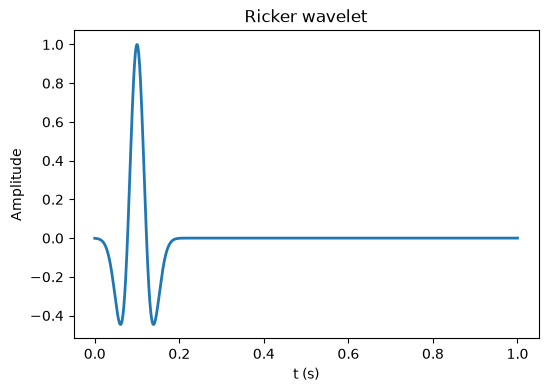

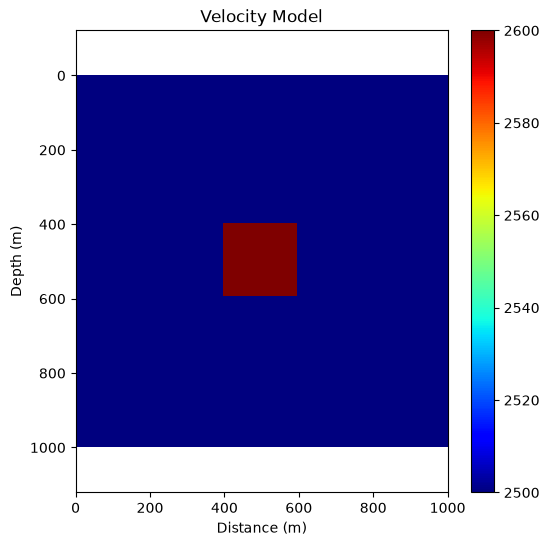

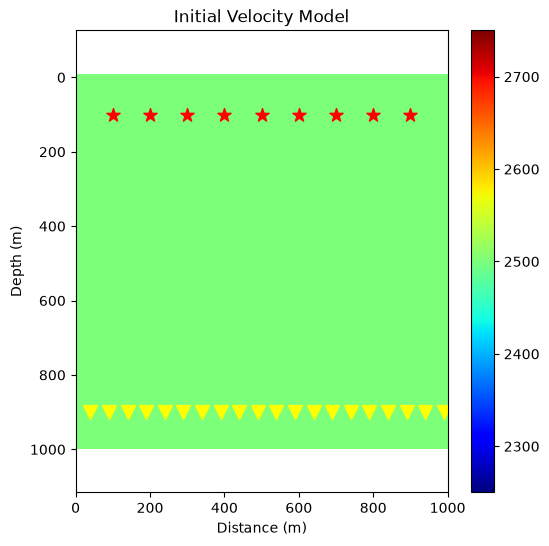

In [2]:
#===========================================
#  Parameters
#===========================================
nx = 101
nz = 101
dx = 10.0
dz = 10.0
x_max = (nx - 1) * dx
z_max = (nz - 1) * dz
dt = 0.001
tmax = 1.0
nt = int(tmax / dt) + 1
t = np.arange(0, tmax + dt, dt)
#===========================================
# Source
#===========================================
f0 = 10.0
t0 = 1/f0
wavelet = ricker(t,f0,t0)
wavelet = np.asarray(wavelet, dtype=np.float32)
# Plot wavelet
plt.figure(figsize=(6, 4))
plt.plot(t,wavelet,linewidth=2)
plt.xlabel("t (s)")
plt.ylabel("Amplitude")
plt.title("Ricker wavelet")
plt.show()
#===========================================
# Source position
#===========================================
ix_src = np.arange(10,100,10,dtype=np.int32)
# ix_src = np.asarray([0, 50, 100, 150, 200, 250, 300],dtype=np.int32)
# ix_src = np.arange(100,210,10,dtype=np.int32)
iz_src = np.full(len(ix_src),10,dtype=np.int32)

#===========================================
# Receiver position
#===========================================
receivers = np.arange(4,nx-1,5,dtype=np.int32)
# receivers = np.array([51,50],dtype=np.int32)
ix_receiver = multi_shot_acquisition(ix_src,receivers)
iz_receiver = np.full(ix_receiver.shape,90,dtype=np.int64)
#===========================================
# Velocity model
#===========================================
velocity_model = rectangular_anomaly_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    background_velocity=2500.0,
    anomaly_velocity=2600.0,
    x_min=400.0,
    x_max=600.0,
    z_min=400.0,
    z_max=600.0
)

velocity_ture = np.asarray(velocity_model,dtype=np.float32)
n=-1
# Plot velocity model
plt.figure(figsize=(6, 6))
plt.imshow(
        velocity_ture,
        extent=[0,x_max,z_max,0],
        aspect='auto',
        cmap="jet",
    )
plt.colorbar()
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title("Velocity Model")
plt.axis('equal')
plt.show()

#===========================================
# Initial velocity model
#===========================================
velocity_initial = homogeneous_model(
    nx=nx,
    nz=nz,
    velocity=2500.0)
# velocity_initial = smoothing_velocity_model(velocity_initial, sigma_x=8.0, sigma_z=8.0)
# Plot velocity model
plt.figure(figsize=(6, 6))
plt.imshow(
        velocity_initial,
        extent=[0,x_max,z_max,-10],
        aspect='auto',
        cmap="jet",
    )
plt.colorbar()
plt.scatter(
    ix_receiver[n] * dx,
    iz_receiver[n] * dz,
    marker='v',
    s=100,
    color='yellow'
)
plt.scatter(
    ix_src * dx,
    iz_src * dz,
    marker='*',
    s=100,
    color='red'
)
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title("Initial Velocity Model")
plt.axis('equal')
plt.show()


In [ ]:
# 全流程共用同一吸收层、float64 差分系数和固定 sigma。
# sigma 是数值边界参数，在观测数据生成、梯度和所有试探步中保持不变。
n_abs = 80
order = 8
coeff = np.asarray(fd_coefficients(order), dtype=np.float64)
_, sigma = damping_boundary(
    np.full_like(velocity_initial, 3500.0), dx, dz, n_abs,
    reflection=1e-6, power=2,
)
setup = AcousticSetup(
    wavelet, coeff, ix_src, iz_src, ix_receiver, iz_receiver,
    dx, dz, dt, n_abs, sigma,
)
# FIX: 仅生成炮集，不分配无用的全时刻波场；所有炮采用同一正演配置。
d_obs = simulate_shots(velocity_ture, setup)
print("Observed data:", d_obs.shape)


Observed data: (9, 1001, 20)


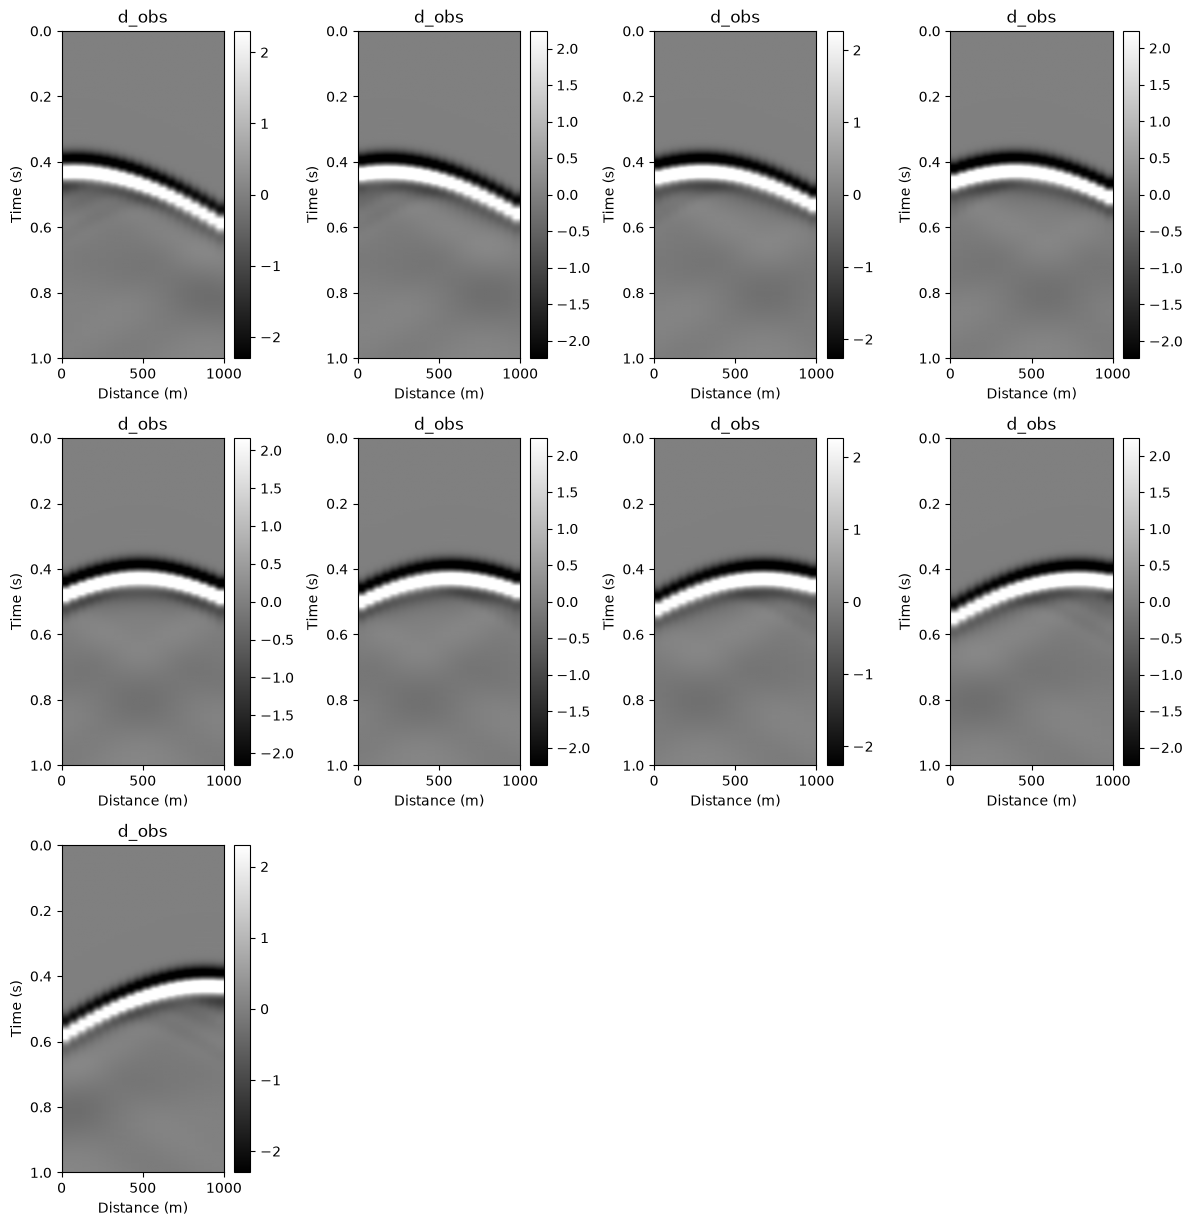

In [5]:
plt.figure(figsize=(12, 16))
for i in range(len(ix_src)):
    # Plot shot gather
    plt.subplot(4, 4, i + 1)
    vmax = np.max(d_obs[i])/2
    plt.imshow(
        d_obs[i],
        extent=[0,x_max,tmax,0],
        aspect='auto',
        cmap="gray",
        vmin=-vmax,
        vmax=vmax,
        )
    plt.xlabel("Distance (m)")
    plt.ylabel("Time (s)")
    plt.colorbar()
    plt.title('d_obs')

plt.tight_layout()
plt.show()

In [6]:
# FIX: 多炮正演、伴随反传与梯度累加均已移入梯度求取函数。
# 每次只保存一炮的速度敏感度，避免 wavefield_tt_all 随炮数占用内存。
objective_initial, gradient_m, gradient_v, d_syn = fwi_objective_gradient(
    velocity_initial, d_obs, setup,
)
print(f"Initial objective J = {objective_initial:.8e}")


Initial objective J = 6.03601352e-01


(9, 1001, 20)


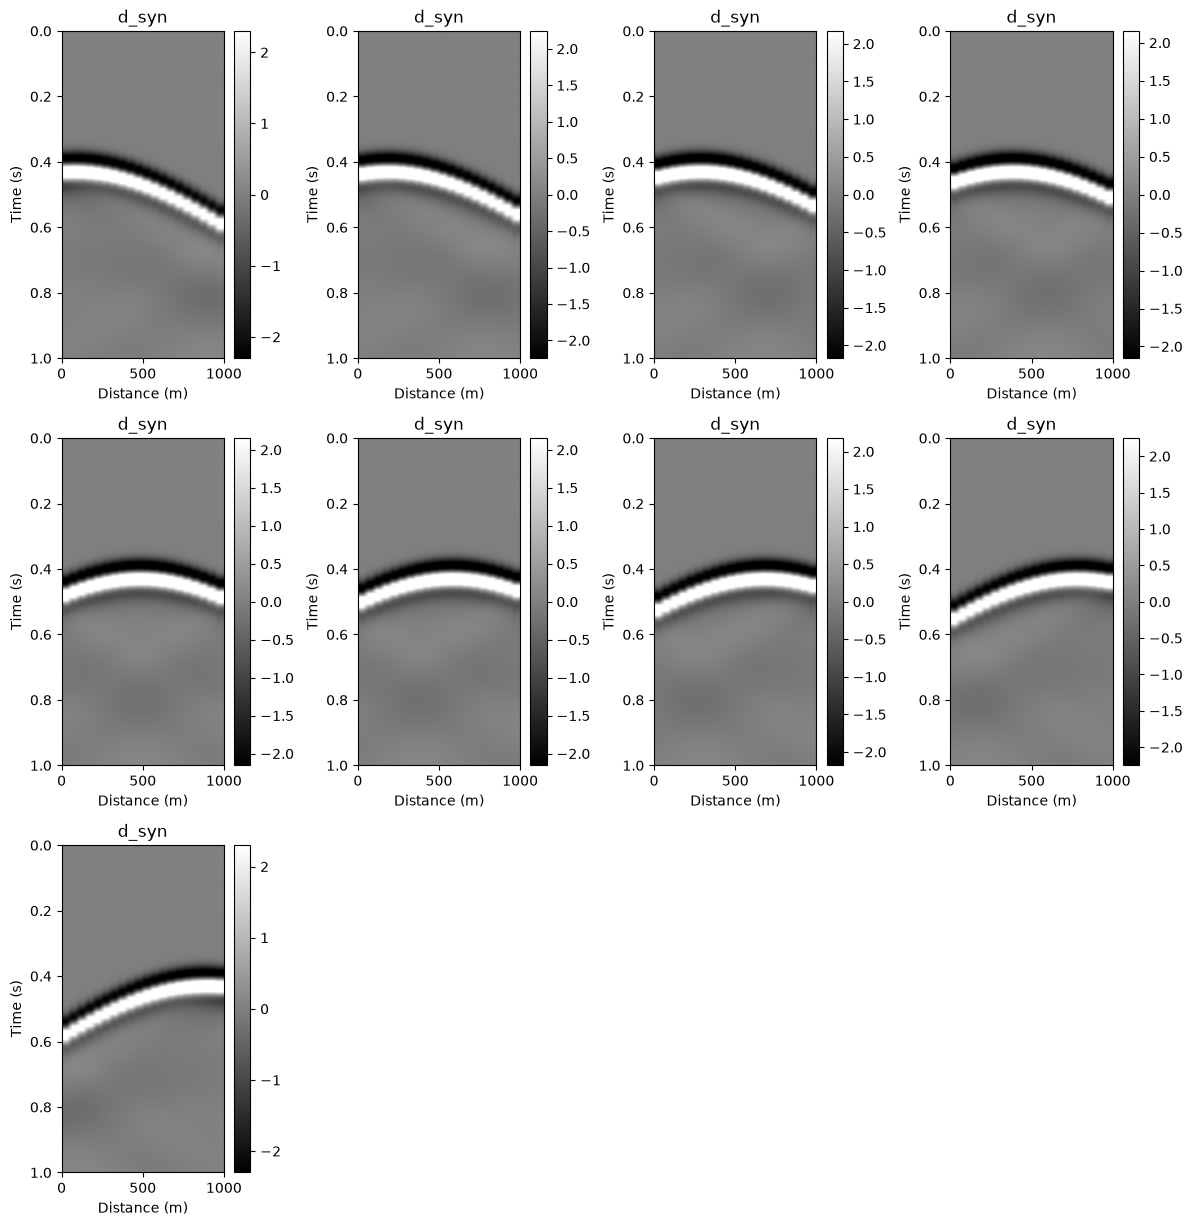

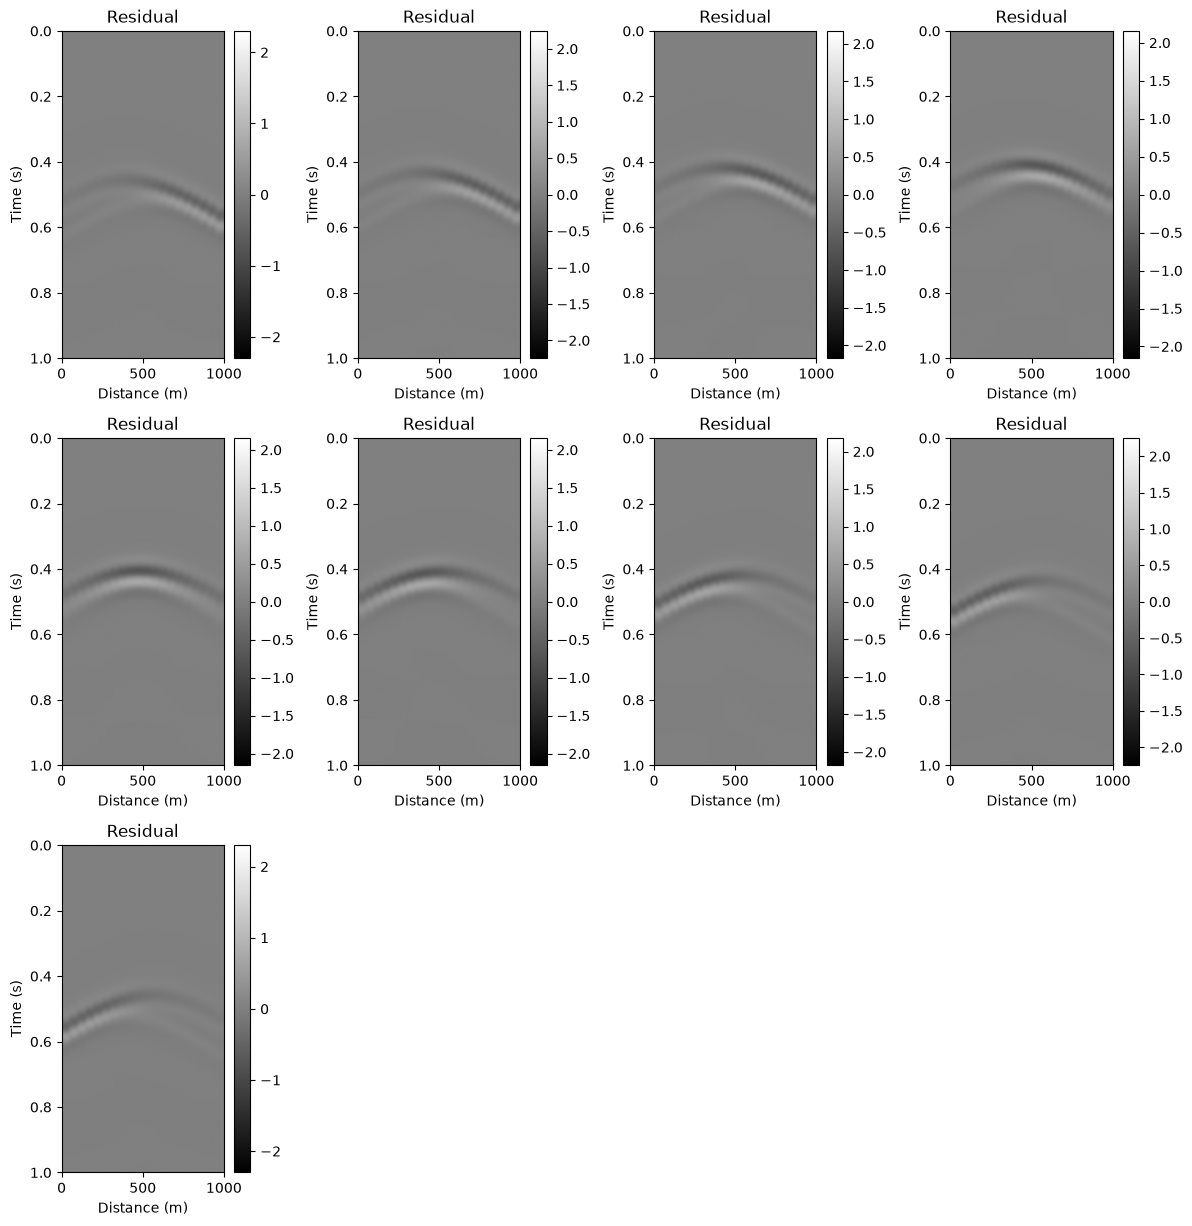

In [7]:
plt.figure(figsize=(12, 16))
print(d_syn.shape)
for i in range(len(ix_src)):
    # Plot shot gather
    plt.subplot(4, 4, i + 1)
    vmax = np.max(d_syn[i])/2
    plt.imshow(
        d_syn[i],
        extent=[0,x_max,tmax,0],
        aspect='auto',
        cmap="gray",
        vmin=-vmax,
        vmax=vmax,
        )
    plt.xlabel("Distance (m)")
    plt.ylabel("Time (s)")
    plt.colorbar()
    plt.title('d_syn')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 16))
for i in range(len(ix_src)):
    # Plot shot gather
    plt.subplot(4, 4, i + 1)
    vmax = np.max(d_syn[i])/2
    plt.imshow(
        d_syn[i]-d_obs[i],
        extent=[0,x_max,tmax,0],
        aspect='auto',
        cmap="gray",
        vmin=-vmax,
        vmax=vmax,
        )
    plt.xlabel("Distance (m)")
    plt.ylabel("Time (s)")
    plt.colorbar()
    plt.title('Residual')
plt.tight_layout()
plt.show()


In [8]:
# FIX: 梯度模块已经完成同一离散正演算子的逐炮伴随和叠加。
# 此处不再重建不同厚度的吸收边界，也不再在主程序手工累加炮梯度。
assert gradient_v.shape == velocity_initial.shape
assert np.all(np.isfinite(gradient_v))
print("Summed shots:", len(ix_src))
print("max(abs(gradient_v)) =", np.max(np.abs(gradient_v)))


Summed shots: 9
max(abs(gradient_v)) = 3.839330445520201e-05


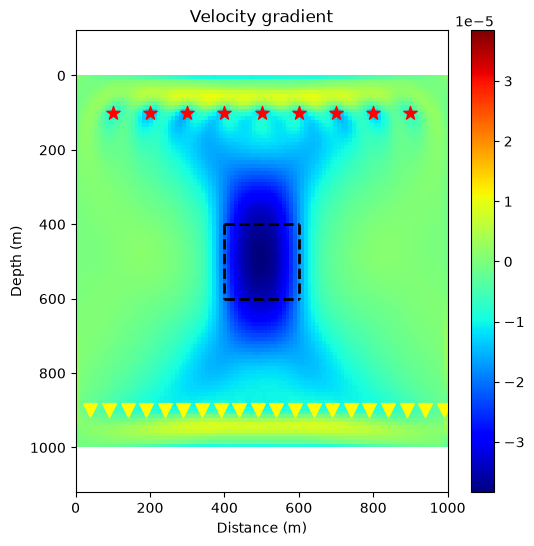

In [9]:
#===========================================
# Velocity gradient
#===========================================
p=700
vmax = np.max(np.abs(gradient_v))
plt.figure(figsize=(6, 6))
plt.imshow(
        gradient_v,
        extent=[0,x_max,z_max,0],
        aspect='auto',
        cmap="jet",
        vmin=-vmax,
        vmax=vmax
    )
plt.colorbar()
plt.scatter(
    ix_receiver[n] * dx,
    iz_receiver[n] * dz,
    marker='v',
    s=100,
    color='yellow'
)
plt.scatter(
    ix_src * dx,
    iz_src * dz,
    marker='*',
    s=100,
    color='red'
)
plt.plot([400,600],[400,400],color='black',linewidth=2,linestyle='--')
plt.plot([400,600],[600,600],color='black',linewidth=2,linestyle='--')
plt.plot([400,400],[400,600],color='black',linewidth=2,linestyle='--')
plt.plot([600,600],[400,600],color='black',linewidth=2,linestyle='--')
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title("Velocity gradient")
plt.axis('equal')
plt.show()

Iteration 01: J=1.00916828e-01, J/J0=0.167191, step=31.198 m/s, search=parabolic
Iteration 02: J=3.12631775e-02, J/J0=0.051794, step=14.181 m/s, search=parabolic
Iteration 03: J=1.61634064e-02, J/J0=0.026778, step=6.148 m/s, search=parabolic
Iteration 04: J=9.90237382e-03, J/J0=0.016405, step=5.759 m/s, search=parabolic
Iteration 05: J=6.95896446e-03, J/J0=0.011529, step=2.884 m/s, search=parabolic
Stop status: max_iterations
Accepted iterations: 5


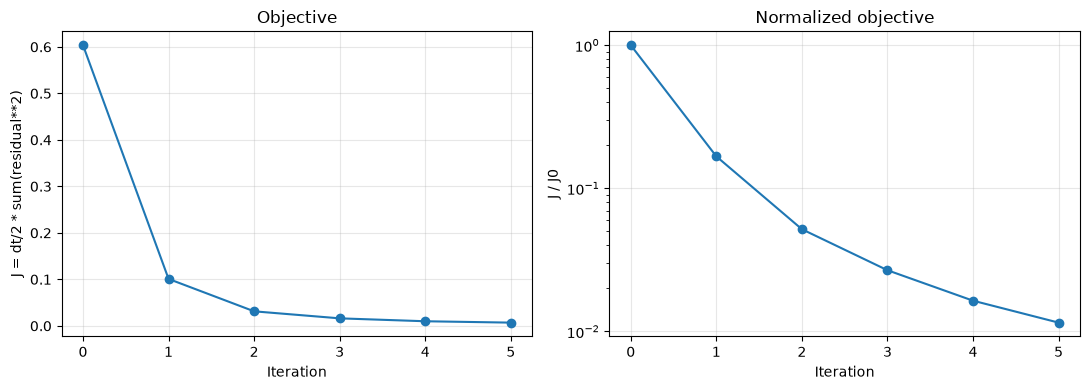

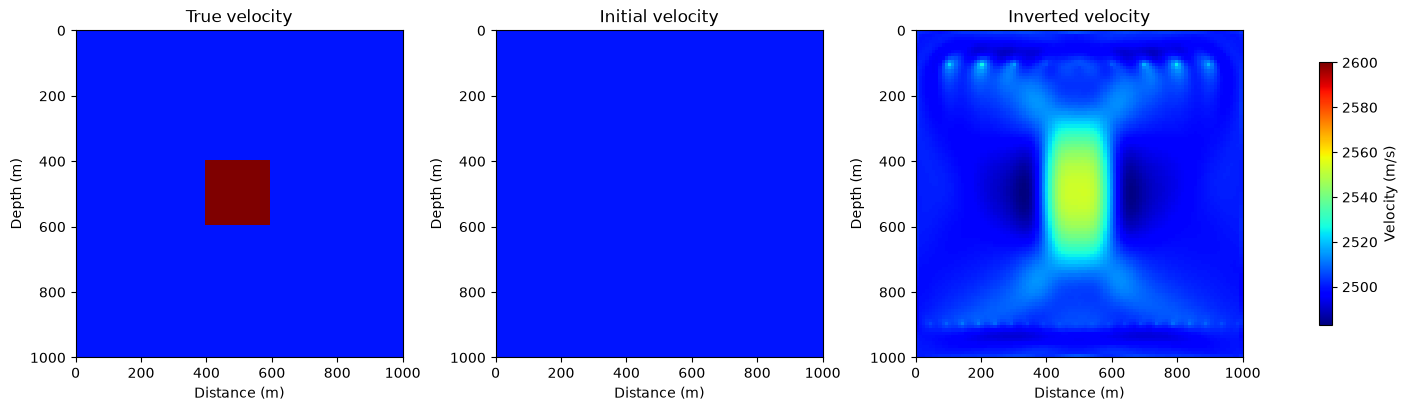

Initial model RMSE: 19.801980198019802
Inverted model RMSE: 14.400479531433339


In [ ]:
# FIX/NEW: 完整 FWI 示例：归一化最速下降 + 有保护的三点抛物线步长。
# 保留当前 101x101、9 炮、10 Hz、1 s 的实验设置。
# p=-g/max|g|，所以 initial_step/max_step 的单位为 m/s。
result = gradient_descent_fwi(
    velocity_initial, d_obs, setup,
    max_iterations=5,
    initial_step=10.0,
    max_step=60.0,
    velocity_bounds=(1800.0, 3500.0),
    relative_tolerance=1e-5,
    max_line_evaluations=6,
)
velocity_inverted = result["velocity"]
objective_history = result["objective_history"]
print("Stop status:", result["status"])
print("Accepted iterations:", result["iterations"])

# FIX: 记录的是每次已接受模型的真实目标函数，包含第 0 次初始模型。
iterations = np.arange(len(objective_history))
denominator = objective_history[0] if objective_history[0] > 0 else 1.0
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(iterations, objective_history, "o-")
axes[0].set(xlabel="Iteration", ylabel="J = dt/2 * sum(residual**2)", title="Objective")
axes[1].semilogy(iterations, np.maximum(objective_history/denominator, 1e-16), "o-")
axes[1].set(xlabel="Iteration", ylabel="J / J0", title="Normalized objective")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
output_dir = Path("fwi_results")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "objective_history.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
vmin = min(velocity_ture.min(), velocity_initial.min(), velocity_inverted.min())
vmax = max(velocity_ture.max(), velocity_initial.max(), velocity_inverted.max())
for ax, model, title in zip(
    axes, [velocity_ture, velocity_initial, velocity_inverted],
    ["True velocity", "Initial velocity", "Inverted velocity"],
):
    im = ax.imshow(model, extent=[0, x_max, z_max, 0], cmap="jet",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.set(title=title, xlabel="Distance (m)", ylabel="Depth (m)")
fig.colorbar(im, ax=axes, label="Velocity (m/s)", shrink=0.8)
fig.savefig(output_dir / "velocity_models.png", dpi=160)
plt.show()
np.savez_compressed(
    output_dir / "inversion_result.npz",
    velocity_true=velocity_ture, velocity_initial=velocity_initial,
    velocity_inverted=velocity_inverted, objective_history=objective_history,
    velocity_history=result["velocity_history"], step_history=result["step_history"],
    raw_step_history=result["raw_step_history"], status=result["status"],
)
print("Initial model RMSE:", np.sqrt(np.mean((velocity_initial-velocity_ture)**2)))
print("Inverted model RMSE:", np.sqrt(np.mean((velocity_inverted-velocity_ture)**2)))